# Israeli Actors Graph — Graph Construction & Period Split

Builds the actor co-appearance graph from `cast_edges.csv` and splits it
into the three analysis periods:

- **A**: year ≤ 1970
- **B**: 1970 < year ≤ 1990
- **C**: year > 1990

**Graph model**: one canonical `nx.MultiGraph` — a node per actor, and one
edge per co-starring *pair* per *film* (so two actors who worked together on
three separate films get three parallel edges, each tagged with that film's
title/year/genre). Each period's analysis graph is a simple weighted
`nx.Graph` derived from it: multi-edges collapse into a single edge with
`weight` = number of shared films.

Actor nodes carry attributes derived **only from film-page data already
collected** — no separate scrape of individual actors' own Wikipedia pages:
genres acted in, billing position (lead vs. supporting), and directors
worked with.

In [1]:
import os
import sys

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))
sys.path.insert(0, os.path.abspath("../.."))  # repo root, for utils.py
import graph_build
import utils  # course helpers: print_graph_info, get_giant_component, log_log_plot

if sys.stdout.encoding and sys.stdout.encoding.lower() != "utf-8":
    sys.stdout.reconfigure(encoding="utf-8")

plt.rcParams["font.family"] = "Arial"  # better Hebrew glyph coverage than the default

## Load cast edges & build the full graph

In [2]:
cast_edges = graph_build.load_cast_edges("../data/processed/cast_edges.csv")
print(f"{len(cast_edges)} cast rows across {cast_edges['movie_slug'].nunique()} films.")

G = graph_build.build_full_graph(cast_edges)
utils.print_graph_info(G)

2972 cast rows across 759 films.


Graph is undirected and unweighted.
Graph is disconnected.
Number of nodes:	  1,399
Number of edges:	  6,543
Density:		0.007


## Split into periods

Each period keeps isolated actors (credited in a film that produced no
identifiable co-star) so per-period actor *counts* stay accurate, even
though isolated nodes get excluded from connectivity metrics like diameter
later on.

In [3]:
periods = {p: graph_build.period_subgraph(G, p) for p in ["A", "B", "C"]}

rows = []
for p, H in periods.items():
    comp_sizes = sorted((len(c) for c in nx.connected_components(H)), reverse=True) if H.number_of_nodes() else [0]
    rows.append({
        "period": p,
        "actors": H.number_of_nodes(),
        "isolated_actors": sum(1 for n in H.nodes if H.degree(n) == 0),
        "collaborations": H.number_of_edges(),
        "density": nx.density(H),
        "avg_clustering": nx.average_clustering(H),
        "n_components": len(comp_sizes),
        "largest_component": comp_sizes[0],
    })

period_stats = pd.DataFrame(rows).set_index("period")
period_stats

,actors,isolated_actors,collaborations,density,avg_clustering,n_components,largest_component
period,,,,,,,
A,132,1,472,0.054592,0.741525,3,128
B,335,9,930,0.016623,0.659384,24,289
C,1106,16,4731,0.007742,0.750682,49,989


## Comparing periods at a glance

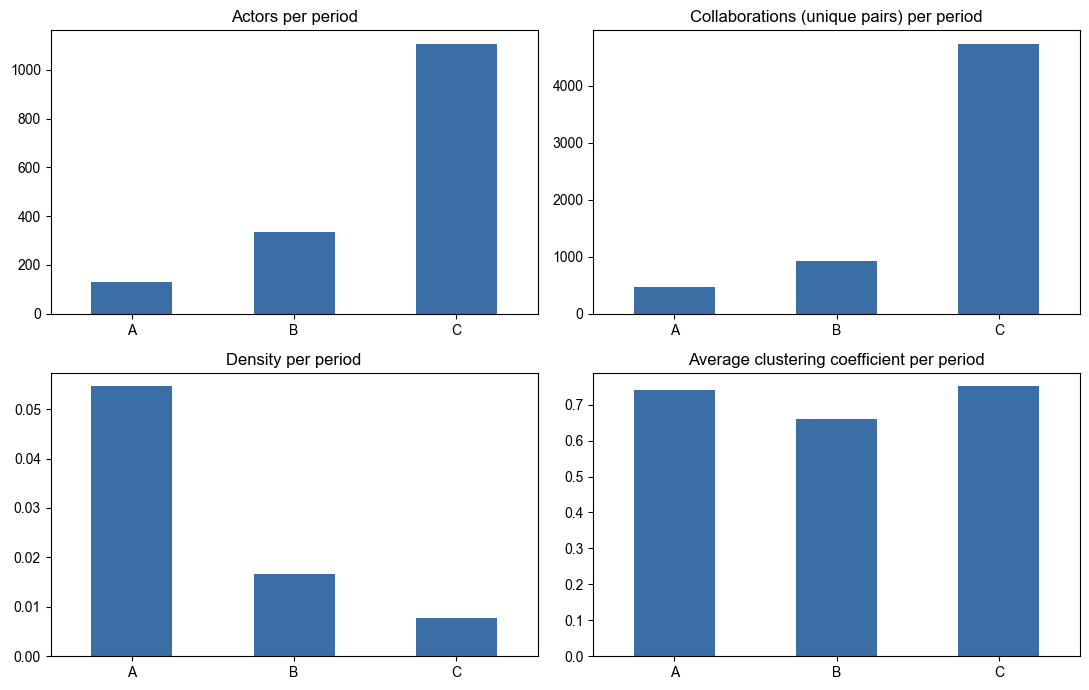

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

period_stats["actors"].plot(kind="bar", ax=axes[0, 0], color="#3b6ea5")
axes[0, 0].set_title("Actors per period")

period_stats["collaborations"].plot(kind="bar", ax=axes[0, 1], color="#3b6ea5")
axes[0, 1].set_title("Collaborations (unique pairs) per period")

period_stats["density"].plot(kind="bar", ax=axes[1, 0], color="#3b6ea5")
axes[1, 0].set_title("Density per period")

period_stats["avg_clustering"].plot(kind="bar", ax=axes[1, 1], color="#3b6ea5")
axes[1, 1].set_title("Average clustering coefficient per period")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Degree distributions

Log-log plots (via the course's `utils.log_log_plot` helper) show whether
the degree distribution is heavy-tailed, as is typical of collaboration
networks (a few very prolific/well-connected actors, many with few
co-stars).

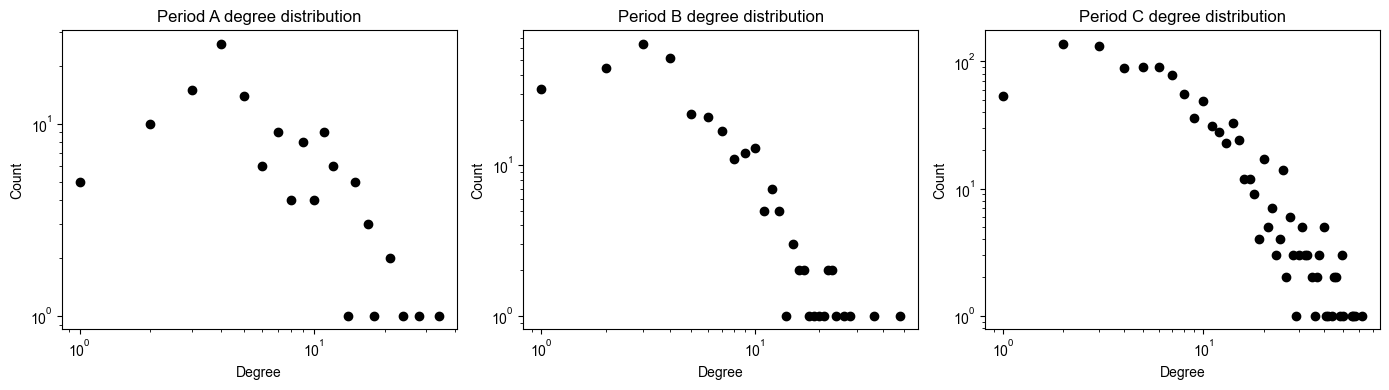

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, p in zip(axes, ["A", "B", "C"]):
    degrees = np.array([d for _, d in periods[p].degree()])
    utils.log_log_plot(degrees, str_title=f"Period {p} degree distribution", ax=ax)
plt.tight_layout()
plt.show()

## Visualizing the network

Period A's graph is small enough to draw legibly in full. Periods B and C
are too large for a readable full-network picture (a "hairball") — instead
we show the induced subgraph of the 50 highest-degree actors, a common way
to keep a large network's picture interpretable (full community-level
visualizations come in the community-detection notebook).

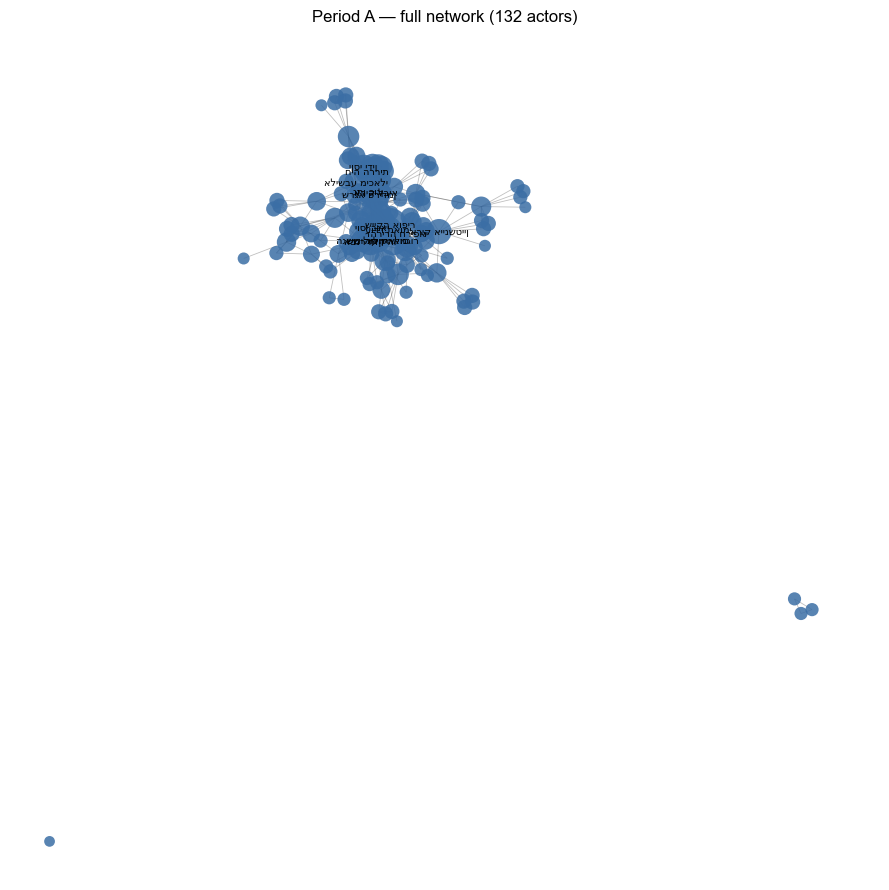

In [6]:
def draw_graph(H, title, ax, label_top_n=15):
    degrees = dict(H.degree())
    sizes = [60 + 15 * degrees[n] for n in H.nodes]
    pos = nx.spring_layout(H, seed=42, k=0.6 / np.sqrt(max(H.number_of_nodes(), 1)))
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.25, width=0.6)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=sizes, node_color="#3b6ea5", alpha=0.85, linewidths=0)

    top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:label_top_n]
    labels = {n: H.nodes[n].get("display_name", n) for n in top_nodes}
    nx.draw_networkx_labels(H, pos, labels=labels, ax=ax, font_size=7)
    ax.set_title(title)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(9, 9))
draw_graph(periods["A"], f"Period A — full network ({periods['A'].number_of_nodes()} actors)", ax)
plt.tight_layout()
plt.show()

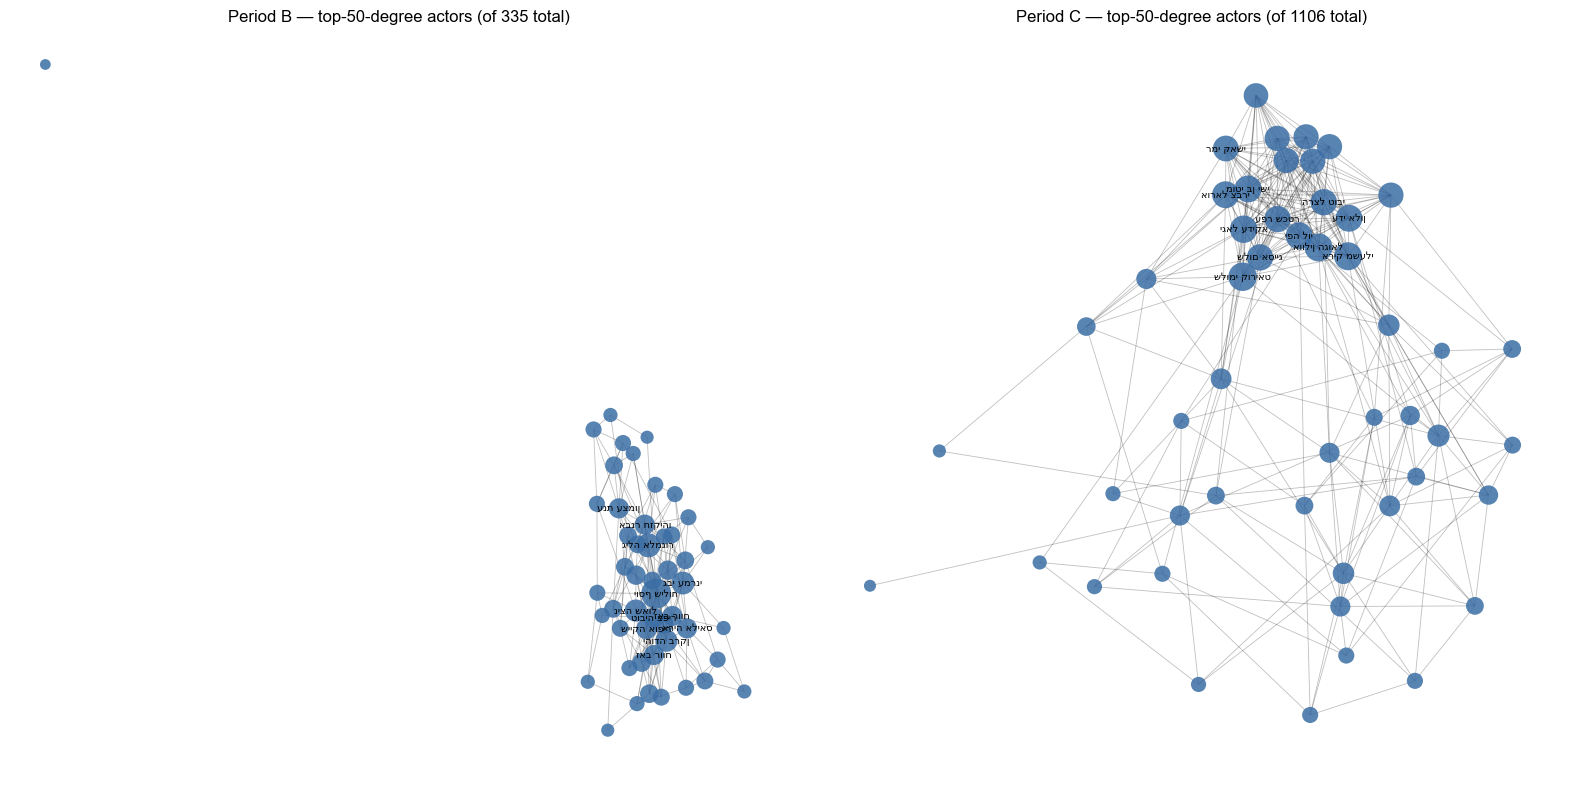

In [7]:
def top_degree_subgraph(H, n=50):
    top_nodes = sorted(dict(H.degree()), key=lambda n_: H.degree(n_), reverse=True)[:n]
    return H.subgraph(top_nodes)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, p in zip(axes, ["B", "C"]):
    sub = top_degree_subgraph(periods[p], n=50)
    draw_graph(sub, f"Period {p} — top-50-degree actors (of {periods[p].number_of_nodes()} total)", ax, label_top_n=12)
plt.tight_layout()
plt.show()

## Save the graphs for reuse in later notebooks

In [8]:
import pickle

try:
    with open("../data/processed/full_graph.pkl", "wb") as f:
        pickle.dump(G, f)
    with open("../data/processed/period_graphs.pkl", "wb") as f:
        pickle.dump(periods, f)
    print("Saved full_graph.pkl and period_graphs.pkl to data/processed/")
except PermissionError:
    print("Could not write the .pkl files (likely locked by another program) -- skipping save.")

Saved full_graph.pkl and period_graphs.pkl to data/processed/


## Next steps

- `03_temporal_period_analysis.ipynb`: full metric suite per period (radius,
  diameter, connected components) plus a written comparison.
- `04_community_detection.ipynb`: Louvain / greedy-modularity / label
  propagation on Period C.
- `05_centrality_analysis.ipynb`, `06_link_prediction.ipynb`.